In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy import constants as const

In [2]:
# Define constants
e = const.e
c = const.c # Speed of light
h = const.h # Planck number

In [3]:
# Data arrays and 1. calculations
# Background measurements: 3 x 50s
t_background = 50.0
u_counts = np.array([13, 11, 12])
u_mean = np.mean(u_counts)
u_std = np.std(u_counts)
u_err = u_std / np.sqrt(3)
print(f"Mean background in 50s: {u_mean:.2f} ")
print(f"With error: {u_err:.3f}")

Mean background in 50s: 12.00 
With error: 0.471


In [4]:
# Evaluation of counting statistics with Cs137 and 1 Pb plate: 50 x 1s
t = 1.0
counts = np.array([10, 9, 7, 4, 3, 9, 7, 5, 7, 10, 11, 7, 14, 10, 9, 3, 8, 5, 8, 8, 15, 11, 14, 13, 7, 9, 13, 8, 6, 4, 8, 11, 10, 13, 7, 13, 7, 10, 8, 9, 12, 9, 11, 7, 11, 11, 14, 10, 9, 8])
mean = np.mean(counts)
m_std = np.std(counts)
m_err = m_std / np.sqrt(len(counts))
m_poisson = np.sqrt(mean)
print(f"Std with counting statistics: {m_std:.3f}, with error {m_err:.3f}")
print(f"Std with poisson: {m_poisson:.3f} Stösse/1s")

Std with counting statistics: 2.884, with error 0.408
Std with poisson: 3.007 Stösse/1s


In [5]:
# Measurements of Cs  with different amount of lead plates
# Up to 10 plates, for t = 50s each
t_abs = 50.0
d_lead = 4 #mm
n_lead = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
counts_lead = np.array([742, 458, 307, 175, 108, 70, 39, 27, 28, 16, 11])
lead_rates_50 = counts_lead  - u_mean # Counting rate with background correction
lead_counts_err = np.sqrt(counts_lead + u_mean / 3)
print(lead_rates_50)
print(lead_counts_err)

[730. 446. 295. 163.  96.  58.  27.  15.  16.   4.  -1.]
[27.31300057 21.49418526 17.63519209 13.37908816 10.58300524  8.60232527
  6.55743852  5.56776436  5.65685425  4.47213595  3.87298335]


In [6]:
# Measurements of Cs  with different amount of aluminum plates
# Up to 5 plates, for t = 50s each
t_abs = 50.0
d_alu = 20 #mm
n_alu = np.array([0, 1, 2, 3, 4, 5])
counts_alu = np.array([889, 522, 339, 205, 174, 118])
alu_rates_50 = counts_alu  - u_mean # Counting rate with background correction
alu_counts_err = np.sqrt(counts_alu + u_mean / 3)
alu_counts_log = np.log(alu_rates_50)
print(alu_rates_50)
print(alu_counts_err)
print(alu_counts_log)

[877. 510. 327. 193. 162. 106.]
[29.88310559 22.93468988 18.52025918 14.45683229 13.34166406 11.04536102]
[6.77650699 6.23441073 5.78996017 5.26269019 5.08759634 4.66343909]


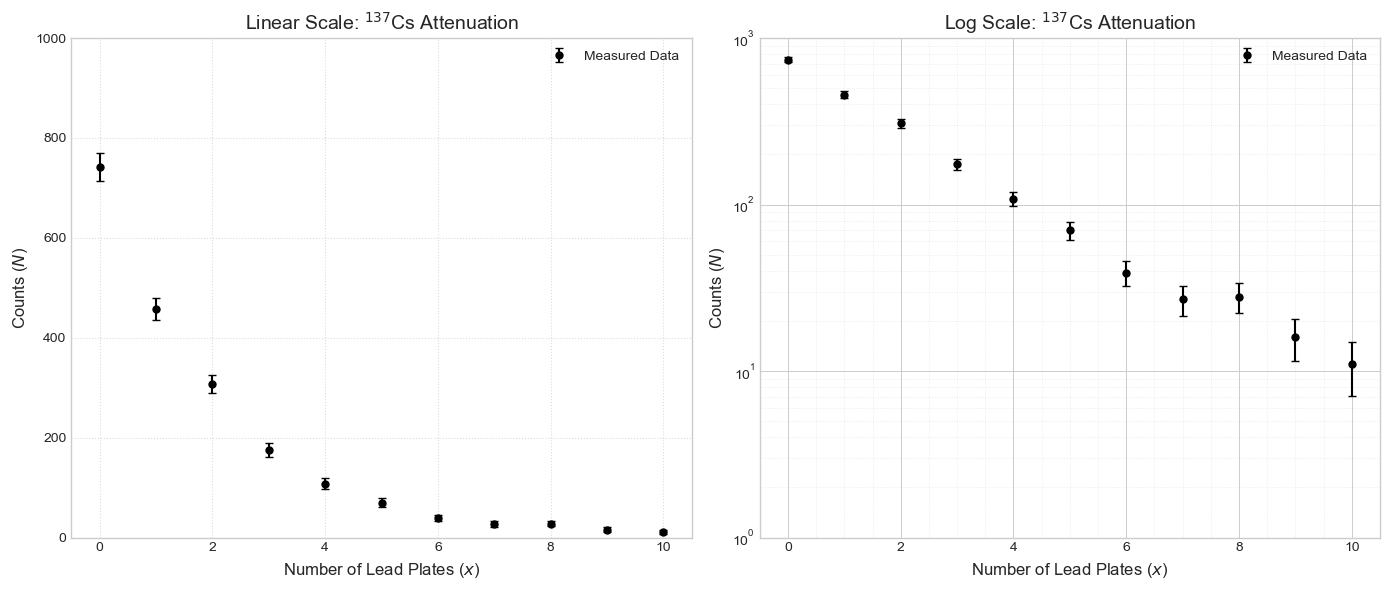

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- LEFT PLOT: Raw Data (Linear Scale) ---
ax1.errorbar(n_lead, counts_lead, yerr=lead_counts_err,
             fmt='ko', markersize=5, capsize=3, label='Measured Data')
ax1.set_title("Linear Scale: $^{137}$Cs Attenuation", fontsize=14)
ax1.set_xlabel("Number of Lead Plates ($x$)", fontsize=12)
ax1.set_ylabel("Counts ($N$)", fontsize=12)
ax1.set_ylim(0, 1000)  # Starts at exactly 0
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.legend()

# --- RIGHT PLOT: Semi-Log Scale ---
ax2.errorbar(n_lead, counts_lead, yerr=lead_counts_err,
             fmt='ko', markersize=5, capsize=3, label='Measured Data')
ax2.set_yscale("log")
ax2.set_title("Log Scale: $^{137}$Cs Attenuation", fontsize=14)
ax2.set_xlabel("Number of Lead Plates ($x$)", fontsize=12)
ax2.set_ylabel("Counts ($N$)", fontsize=12)

# Log limit: starts at 1 (10^0) as log(0) is undefined
ax2.set_ylim(1, 1000)

# Add minor ticks and major/minor grids for the log scale
ax2.minorticks_on()
ax2.grid(True, which='major', linestyle='-', linewidth=0.7)
ax2.grid(True, which='minor', linestyle=':', linewidth=0.5, alpha=0.5)
ax2.legend()

plt.tight_layout() # Prevents subplots from overlapping
plt.show()

In [17]:
# Perform a fit of the measured data using scipy optimize
def exp(x, a, u,):
    return a * np.e**(-u*x)

popt, pcof = curve_fit(f = exp,
                       xdata=n_lead[:6],
                       ydata=counts_lead[:6],
                       sigma=lead_counts_err[:6])

amplitude, nu = popt
amplutude_error, nu_error = np.diag(pcof)

print(nu)
print(nu_error)

0.4739293158244729
9.701999573636928e-05


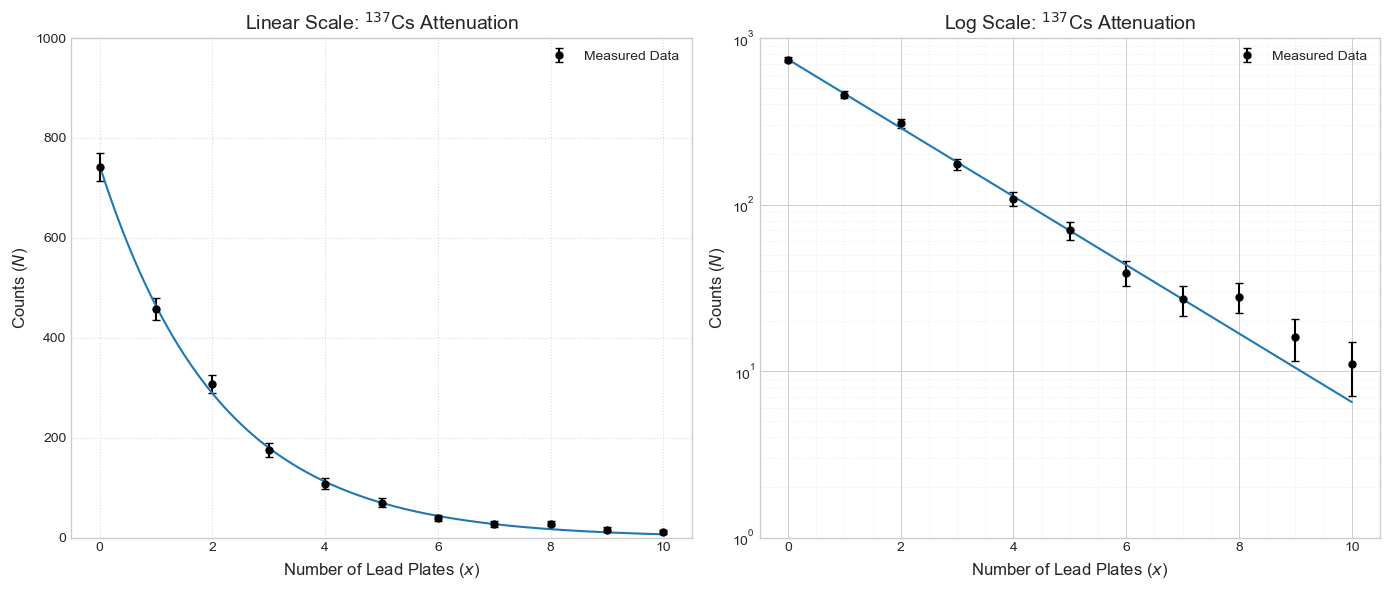

In [18]:
n_lead_smooth = np.linspace(0, 10, 200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- LEFT PLOT: Raw Data (Linear Scale) ---
ax1.errorbar(n_lead, counts_lead, yerr=lead_counts_err,
             fmt='ko', markersize=5, capsize=3, label='Measured Data')
ax1.plot(n_lead_smooth, exp(n_lead_smooth, amplitude, nu))
ax1.set_title("Linear Scale: $^{137}$Cs Attenuation", fontsize=14)
ax1.set_xlabel("Number of Lead Plates ($x$)", fontsize=12)
ax1.set_ylabel("Counts ($N$)", fontsize=12)
ax1.set_ylim(0, 1000)  # Starts at exactly 0
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.legend()

# --- RIGHT PLOT: Semi-Log Scale ---
ax2.errorbar(n_lead, counts_lead, yerr=lead_counts_err,
             fmt='ko', markersize=5, capsize=3, label='Measured Data')
ax2.plot(n_lead_smooth, exp(n_lead_smooth, amplitude, nu))
ax2.set_yscale("log")
ax2.set_title("Log Scale: $^{137}$Cs Attenuation", fontsize=14)
ax2.set_xlabel("Number of Lead Plates ($x$)", fontsize=12)
ax2.set_ylabel("Counts ($N$)", fontsize=12)

# Log limit: starts at 1 (10^0) as log(0) is undefined
ax2.set_ylim(1, 1000)

# Add minor ticks and major/minor grids for the log scale
ax2.minorticks_on()
ax2.grid(True, which='major', linestyle='-', linewidth=0.7)
ax2.grid(True, which='minor', linestyle=':', linewidth=0.5, alpha=0.5)
ax2.legend()

plt.tight_layout() # Prevents subplots from overlapping
plt.show()

In [20]:
# Measurement of de-ionized water, once full pipe and once empty pipe of 10cm length for t = 50s
t_water = 50.0
counts_full = 320.0
counts_empty = 618.0
counts_water = counts_empty -counts_full
print(f"Counts water: {counts_water:.3f}")

Counts water: 298.000
